In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
TRAIN_PATH   = '../data/raw/cell2celltrain.csv'
HOLDOUT_PATH = '../data/raw/cell2cellholdout.csv'

df    = pd.read_csv(TRAIN_PATH)
holdout = pd.read_csv(HOLDOUT_PATH)

print(f"Train shape    : {df.shape}")
print(f"Holdout shape  : {holdout.shape}")
print(f"Columns        : {list(df.columns)}")

Train shape    : (51047, 58)
Holdout shape  : (20000, 58)
Columns        : ['CustomerID', 'Churn', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'ServiceArea', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUser', 'NotNewCellphoneUser', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'OwnsMotorcycle',

In [3]:
df.head(5)

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.00,22.00,0.25,0.00,0.00,-157.00,-19.00,0.70,0.70,6.30,0.00,0.00,97.20,0.00,0.00,58.00,24.00,1.30,0.00,0.30,61,2,1,SEAPOR503,2.00,2.00,361.00,62.00,0.00,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.00,17.00,0.00,0.00,0.00,-4.00,0.00,0.30,0.00,2.70,0.00,0.00,0.00,0.00,0.00,5.00,1.00,0.30,0.00,0.00,58,1,1,PITHOM412,2.00,1.00,1504.00,40.00,42.00,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.00,38.00,0.00,0.00,0.00,-2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.40,0.30,0.00,1.30,3.70,0.00,0.00,0.00,60,1,1,MILMIL414,1.00,1.00,1812.00,26.00,26.00,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.00,75.00,1.24,0.00,0.00,157.00,8.10,52.00,7.70,76.00,4.30,1.30,200.30,370.30,147.00,555.70,303.70,59.70,0.00,22.70,59,2,2,PITHOM412,9.00,4.00,458.00,30.00,0.00,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.00,17.00,0.00,0.00,0.00,0.00,-0.20,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,53,2,2,OKCTUL918,4.00,3.00,852.00,46.00,54.00,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [4]:
df.info()
print("\nNumeric columns  :", df.select_dtypes('number').shape[1])
print("Categorical cols :", df.select_dtypes('object').shape[1])

<class 'pandas.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  str    
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  float64
 14  T

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,51047.00,NaN,NaN,NaN,3201956.88,116905.56,3000002.00,3100632.00,3201534.00,3305376.00,3399994.00
Churn,51047,2,No,36336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyRevenue,50891.00,NaN,NaN,NaN,58.83,44.51,-6.17,33.61,48.46,71.06,1223.38
MonthlyMinutes,50891.00,NaN,NaN,NaN,525.65,529.87,0.00,158.00,366.00,723.00,7359.00
TotalRecurringCharge,50891.00,NaN,NaN,NaN,46.83,23.85,-11.00,30.00,45.00,60.00,400.00
DirectorAssistedCalls,50891.00,NaN,NaN,NaN,0.90,2.23,0.00,0.00,0.25,0.99,159.39
OverageMinutes,50891.00,NaN,NaN,NaN,40.03,96.59,0.00,0.00,3.00,41.00,4321.00
RoamingCalls,50891.00,NaN,NaN,NaN,1.24,9.82,0.00,0.00,0.00,0.30,1112.40
PercChangeMinutes,50680.00,NaN,NaN,NaN,-11.55,257.51,-3875.00,-83.00,-5.00,66.00,5192.00
PercChangeRevenues,50680.00,NaN,NaN,NaN,-1.19,39.57,-1107.70,-7.10,-0.30,1.60,2483.50


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct':   missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_df)}")
print(missing_df)

Columns with missing values: 14
                       missing_count  missing_pct
AgeHH2                           909         1.78
AgeHH1                           909         1.78
PercChangeRevenues               367         0.72
PercChangeMinutes                367         0.72
MonthlyRevenue                   156         0.31
MonthlyMinutes                   156         0.31
RoamingCalls                     156         0.31
OverageMinutes                   156         0.31
DirectorAssistedCalls            156         0.31
TotalRecurringCharge             156         0.31
ServiceArea                       24         0.05
Handsets                           1         0.00
CurrentEquipmentDays               1         0.00
HandsetModels                      1         0.00


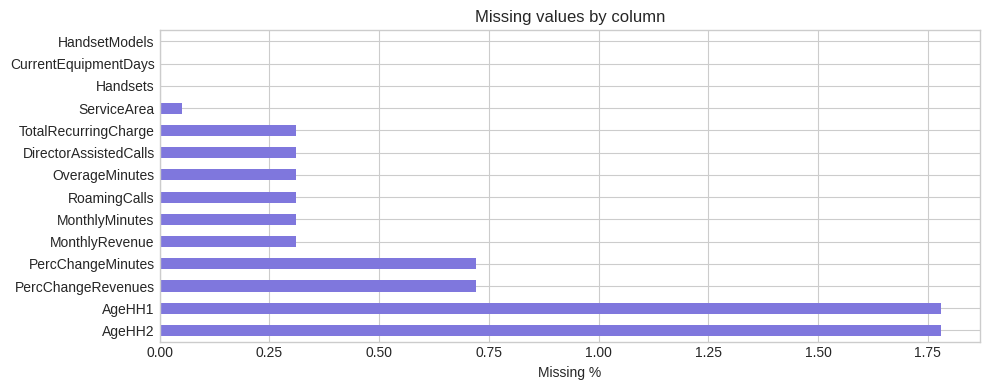

In [7]:
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['missing_pct'].plot(kind='barh', ax=ax, color='#7F77DD')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing values by column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found")

In [8]:
df.columns

Index(['CustomerID', 'Churn', 'MonthlyRevenue', 'MonthlyMinutes',
       'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes',
       'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues',
       'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls',
       'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls',
       'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls',
       'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService',
       'UniqueSubs', 'ActiveSubs', 'ServiceArea', 'Handsets', 'HandsetModels',
       'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH',
       'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner',
       'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers',
       'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard',
       'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUser',
       'NotNewCellphoneUser', 'ReferralsMadeBySubscriber', 'IncomeGro

In [9]:
# See exactly what's inside the column BEFORE mapping
print(df['Churn'].unique())
print(df['Churn'].dtype)
print(df['Churn'].value_counts(dropna=False))

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
str
Churn
No     36336
Yes    14711
Name: count, dtype: int64


In [10]:

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Step 3 — verify
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].mean():.3f}")

Churn
0    36336
1    14711
Name: count, dtype: int64
Churn rate: 0.288


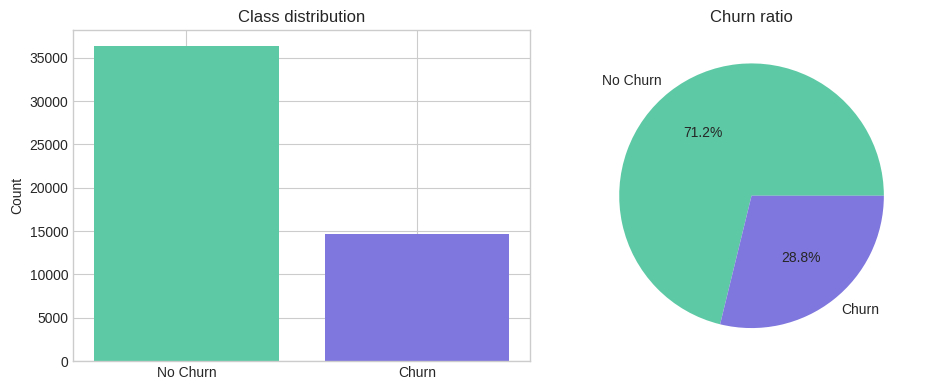

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
counts = df['Churn'].value_counts()
axes[0].bar(['No Churn', 'Churn'], counts.values,
             color=['#5DCAA5', '#7F77DD'])
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=['No Churn','Churn'],
            autopct='%1.1f%%', colors=['#5DCAA5','#7F77DD'])
axes[1].set_title('Churn ratio')

plt.tight_layout()
plt.show()

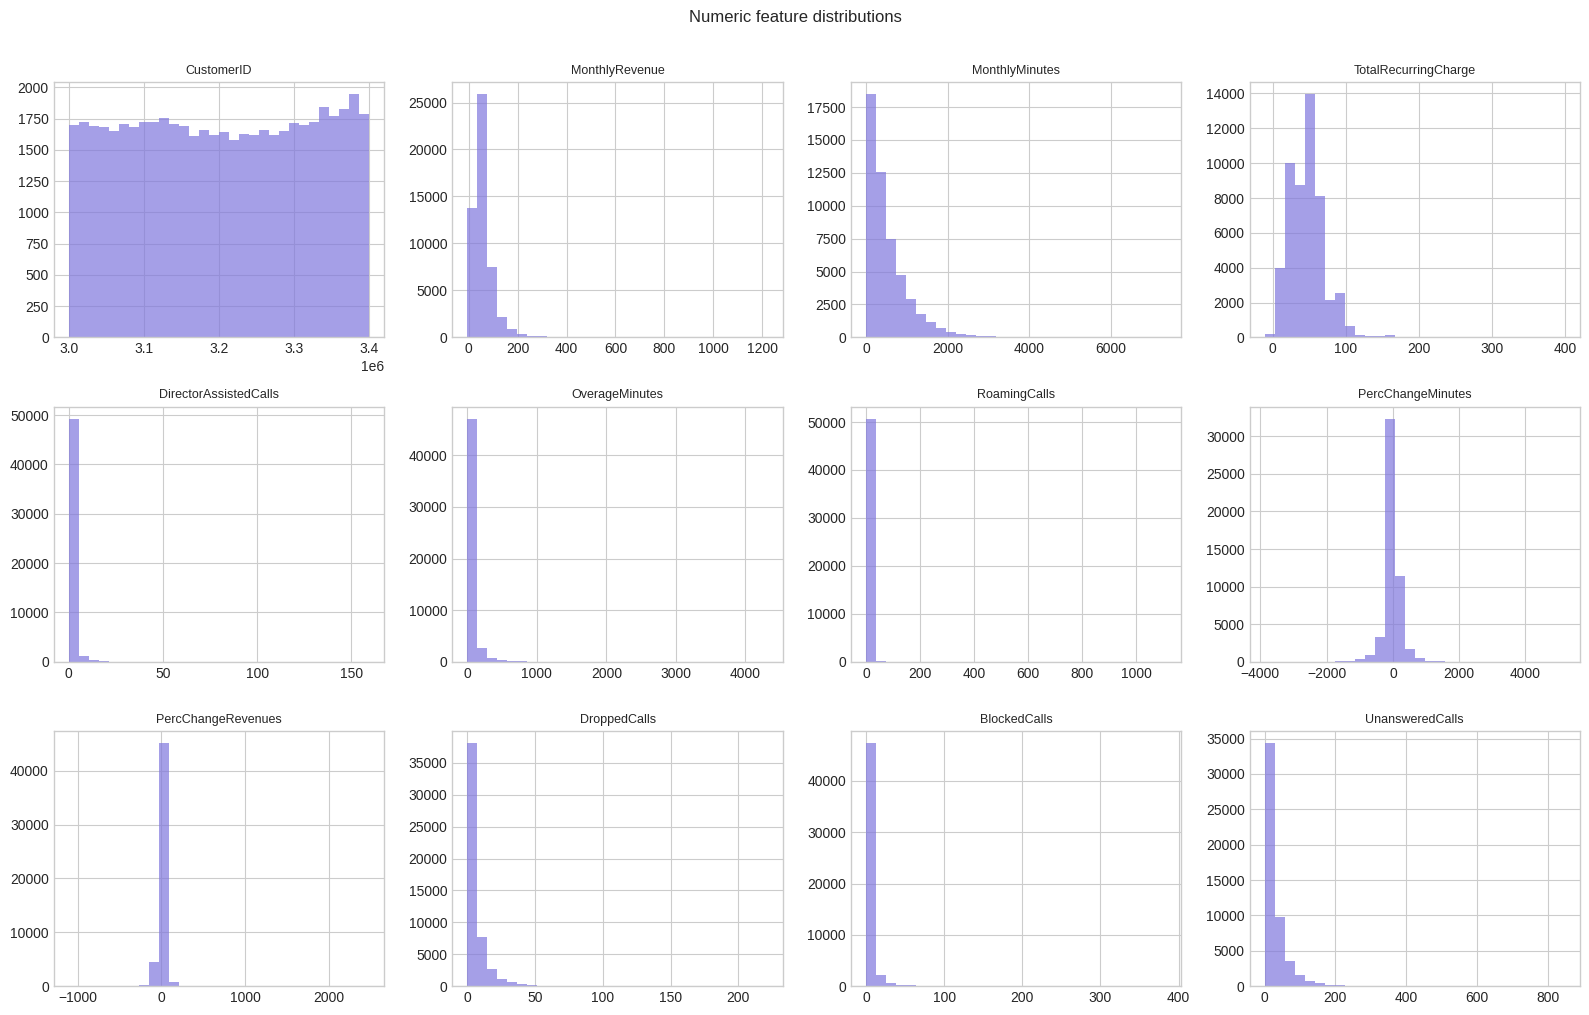

In [12]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'Churn']

# Plot first 12 numeric features
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols[:12]):
    df[col].hist(ax=axes[i], bins=30, color='#7F77DD', alpha=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Numeric feature distributions', y=1.01)
plt.tight_layout()
plt.show()

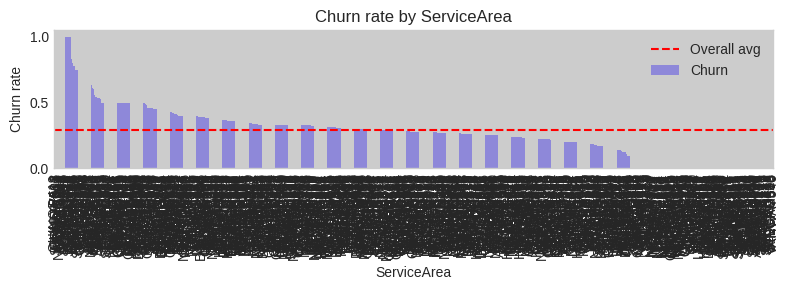

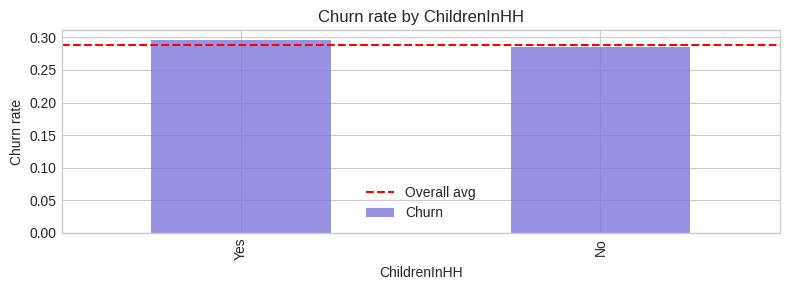

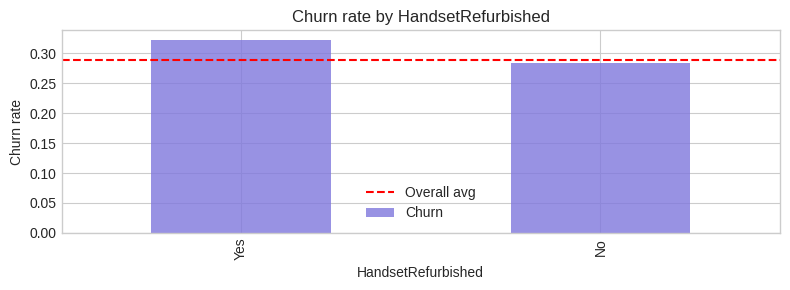

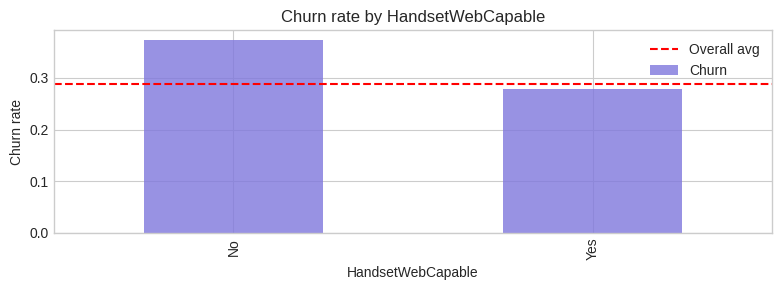

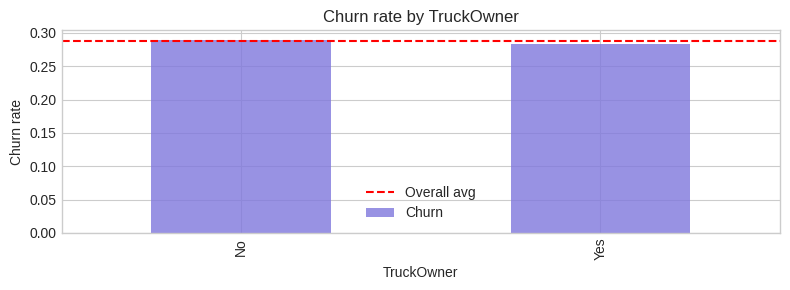

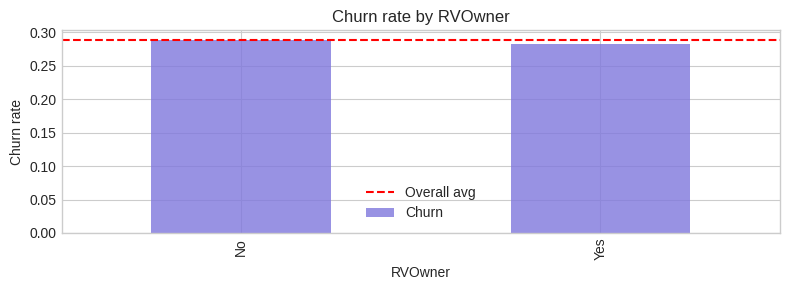

In [13]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols[:6]:
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 3))
    churn_rate.plot(kind='bar', ax=ax, color='#7F77DD', alpha=0.8)
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate')
    ax.axhline(df['Churn'].mean(), color='red', linestyle='--', label='Overall avg')
    ax.legend()
    plt.tight_layout()
    plt.show()

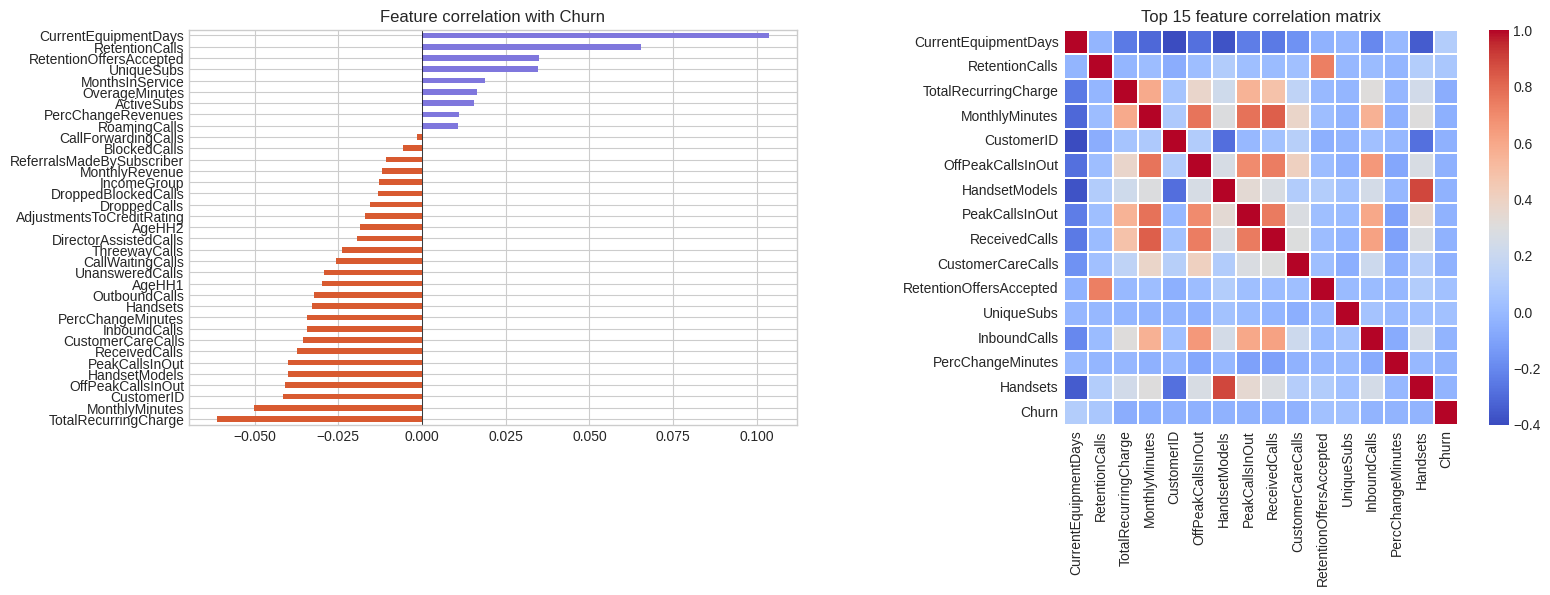

In [14]:
num_df = df[num_cols + ['Churn']].copy()

# Churn is already 0/1 from previous cell — no mapping needed
corr = num_df.corr()
churn_corr = corr['Churn'].drop('Churn').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — bar chart of correlations with Churn
churn_corr.plot(kind='barh', ax=axes[0], color=[
    '#7F77DD' if v > 0 else '#D85A30' for v in churn_corr])
axes[0].set_title('Feature correlation with Churn')
axes[0].axvline(0, color='black', linewidth=0.5)

# Right — heatmap of top 15 features
top_feats = churn_corr.abs().nlargest(15).index.tolist() + ['Churn']
sns.heatmap(num_df[top_feats].corr(),
            ax=axes[1], cmap='coolwarm', annot=False,
            linewidths=0.3, square=True)
axes[1].set_title('Top 15 feature correlation matrix')

plt.tight_layout()
plt.show()

In [15]:
# # Save a quick summary for reference
# summary = {
#     'train_rows':    len(df),
#     'train_cols':    df.shape[1],
#     'churn_rate':    round(df[TARGET].mean(), 4),
#     'missing_cols':  int((df.isnull().sum() > 0).sum()),
#     'numeric_cols':  len(num_cols),
#     'cat_cols':      len(cat_cols),
# }
# import json
# with open('../data/processed/eda_summary.json', 'w') as f:
#     json.dump(summary, f, indent=2)
# print("EDA summary saved.", summary)